# Simple Linear Regression (R)

This notebook reads `regression_data.csv`, plots the data, fits a simple linear regression of **Salary** on **YearsExperience**, overlays the fitted line, and evaluates the model.

**How to run:**

1. Create the conda environment from the project root:
   ```bash
   conda env create -f environment.yml
   conda activate regression-analysis
   ```
2. Open this notebook in Jupyter / RStudio / VS Code / Cursor with the R kernel and run all cells top to bottom.
3. Keep `regression_data.csv` in the same folder as this notebook.

Core modeling uses base R. `ggplot2` (provided by `environment.yml`) is used for plotting when available; otherwise base graphics are used automatically.

## 0. Setup

Uses packages from `environment.yml`. Core modeling uses base R; `ggplot2` is preferred for plotting.

In [1]:
# Prefer packages from the conda environment; fall back to base graphics if ggplot2 is absent.
has_ggplot2 <- requireNamespace("ggplot2", quietly = TRUE)
if (!has_ggplot2) {
  message("ggplot2 not found. Install the conda env (environment.yml) or install.packages('ggplot2'). Using base graphics.")
}
cat("ggplot2 available:", has_ggplot2, "\n")
cat("R version:", R.version.string, "\n")

ggplot2 available: TRUE 


R version: R version 4.5.3 (2026-03-11) 


In [2]:
# Resolve the CSV next to this notebook / in the working directory
candidates <- c(
  file.path(getwd(), "regression_data.csv"),
  "regression_data.csv"
)

# If rstudioapi is available, prefer the folder containing this notebook
if (requireNamespace("rstudioapi", quietly = TRUE) &&
    rstudioapi::isAvailable() &&
    !is.null(rstudioapi::getActiveDocumentContext()$path) &&
    nzchar(rstudioapi::getActiveDocumentContext()$path)) {
  nb_dir <- dirname(rstudioapi::getActiveDocumentContext()$path)
  candidates <- c(file.path(nb_dir, "regression_data.csv"), candidates)
}

data_path <- candidates[file.exists(candidates)][1]

cat("Using data file:", normalizePath(data_path, mustWork = FALSE), "\n")
stopifnot(!is.na(data_path), file.exists(data_path))

Using data file: /Users/lizzieadams/regression-analysis/regression_data.csv 


## 1. Load and inspect the data

In [3]:
df <- read.csv(data_path, stringsAsFactors = FALSE)
cat("Shape:", nrow(df), "rows x", ncol(df), "columns\n")
cat("Columns:", paste(names(df), collapse = ", "), "\n\n")
print(df)

Shape: 10 rows x 2 columns


Columns: YearsExperience, Salary 



   YearsExperience Salary
1              1.1  39343
2              1.3  46205
3              1.5  37731
4              2.0  43525
5              2.2  39891
6              2.9  56642
7              3.0  60150
8              3.2  54445
9              3.7  57189
10             4.0  63218


In [4]:
summary(df)
str(df)

 YearsExperience     Salary     
 Min.   :1.100   Min.   :37731  
 1st Qu.:1.625   1st Qu.:40800  
 Median :2.550   Median :50325  
 Mean   :2.490   Mean   :49834  
 3rd Qu.:3.150   3rd Qu.:57052  
 Max.   :4.000   Max.   :63218  

'data.frame':	10 obs. of  2 variables:
 $ YearsExperience: num  1.1 1.3 1.5 2 2.2 2.9 3 3.2 3.7 4
 $ Salary         : num  39343 46205 37731 43525 39891 ...


## 2. Scatter plot

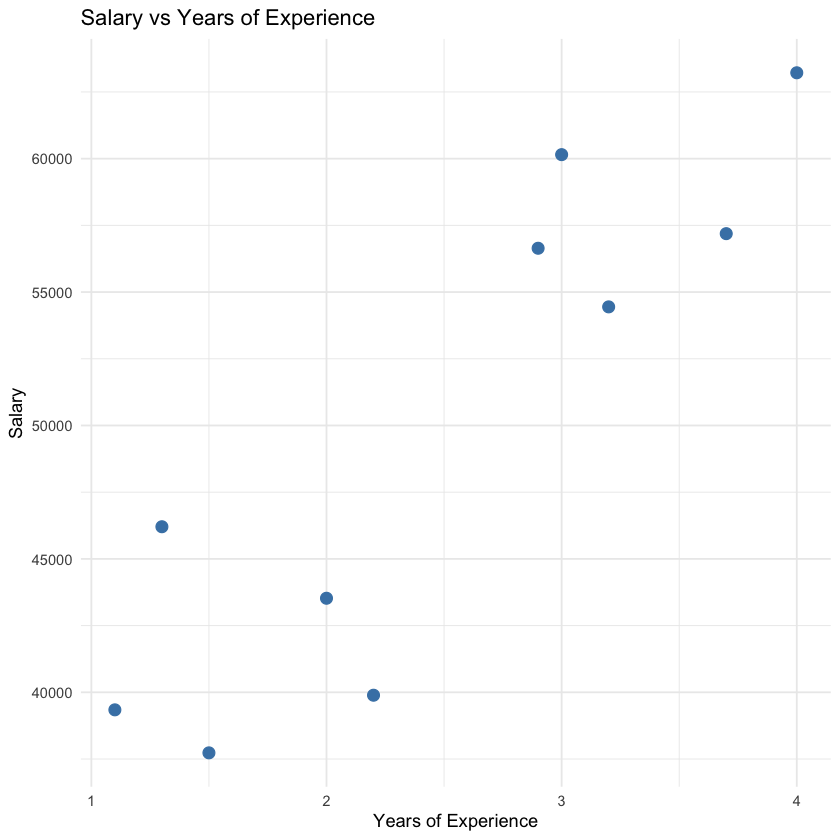

In [5]:
if (has_ggplot2) {
  library(ggplot2)
  print(
    ggplot(df, aes(x = YearsExperience, y = Salary)) +
      geom_point(color = "steelblue", size = 3) +
      labs(
        title = "Salary vs Years of Experience",
        x = "Years of Experience",
        y = "Salary"
      ) +
      theme_minimal()
  )
} else {
  plot(
    df$YearsExperience, df$Salary,
    pch = 19, col = "steelblue",
    xlab = "Years of Experience",
    ylab = "Salary",
    main = "Salary vs Years of Experience"
  )
  grid()
}

## 3. Fit a simple linear regression model

Model: `Salary = intercept + slope * YearsExperience + error`

In [6]:
model <- lm(Salary ~ YearsExperience, data = df)

intercept <- coef(model)[["(Intercept)"]]
slope <- coef(model)[["YearsExperience"]]

cat(sprintf(
  "Fitted model: Salary = %.2f + %.2f * YearsExperience\n",
  intercept, slope
))
cat(sprintf("Intercept: %.4f\n", intercept))
cat(sprintf("Slope:     %.4f\n\n", slope))

print(summary(model))

Fitted model: Salary = 29203.52 + 8285.29 * YearsExperience


Intercept: 29203.5227


Slope:     8285.2921




Call:
lm(formula = Salary ~ YearsExperience, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407



## 4. Overlay the regression line

`geom_smooth()` using formula = 'y ~ x'


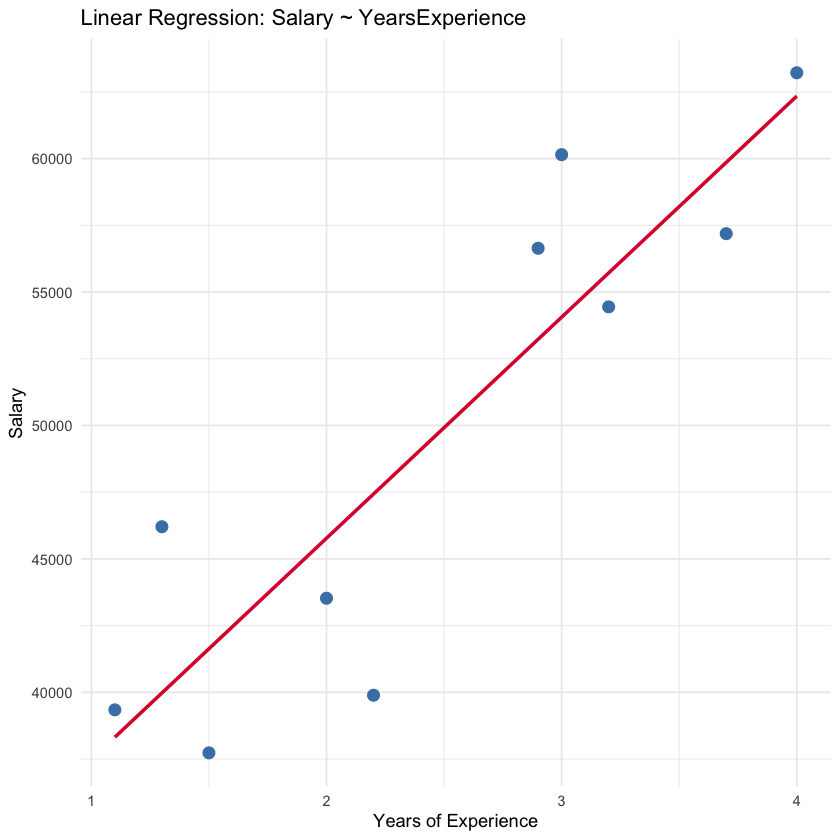

In [7]:
if (has_ggplot2) {
  print(
    ggplot(df, aes(x = YearsExperience, y = Salary)) +
      geom_point(color = "steelblue", size = 3) +
      geom_smooth(method = "lm", se = FALSE, color = "#DC143C", linewidth = 1) +
      labs(
        title = "Linear Regression: Salary ~ YearsExperience",
        x = "Years of Experience",
        y = "Salary"
      ) +
      theme_minimal()
  )
} else {
  plot(
    df$YearsExperience, df$Salary,
    pch = 19, col = "steelblue",
    xlab = "Years of Experience",
    ylab = "Salary",
    main = "Linear Regression: Salary ~ YearsExperience"
  )
  abline(model, col = "#DC143C", lwd = 2)
  grid()
  legend("topleft", legend = c("Observed", "Fitted line"),
         col = c("steelblue", "#DC143C"), pch = c(19, NA), lty = c(NA, 1), lwd = c(NA, 2))
}

## 5. Evaluate the model

In [8]:
y <- df$Salary
y_pred <- fitted(model)
residuals_vec <- residuals(model)

n <- length(y)
p <- 1
r2 <- summary(model)$r.squared
adj_r2 <- summary(model)$adj.r.squared
mae <- mean(abs(residuals_vec))
mse <- mean(residuals_vec^2)
rmse <- sqrt(mse)

cat("Model evaluation\n")
cat(strrep("-", 40), "\n")
cat(sprintf("R-squared:           %.4f\n", r2))
cat(sprintf("Adjusted R-squared:  %.4f\n", adj_r2))
cat(sprintf("MAE:                 %.2f\n", mae))
cat(sprintf("MSE:                 %.2f\n", mse))
cat(sprintf("RMSE:                %.2f\n", rmse))
cat(sprintf("Residual mean:       %.4f\n", mean(residuals_vec)))
cat(sprintf("Residual std. dev.:  %.2f\n", sd(residuals_vec)))

cat("\nANOVA / F-test:\n")
print(anova(model))

Model evaluation


---------------------------------------- 


R-squared:           0.7852


Adjusted R-squared:  0.7583


MAE:                 3526.26


...

RMSE:                4186.15


Residual mean:       -0.0000


Residual std. dev.:  4412.59



ANOVA / F-test:


Analysis of Variance Table

Response: Salary
                Df    Sum Sq   Mean Sq F value    Pr(>F)    
YearsExperience  1 640399142 640399142  29.236 0.0006407 ***
Residuals        8 175238441  21904805                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [9]:
results <- data.frame(
  YearsExperience = df$YearsExperience,
  Salary = y,
  Predicted = as.numeric(y_pred),
  Residual = as.numeric(residuals_vec)
)
print(results)

   YearsExperience Salary Predicted   Residual
1              1.1  39343  38317.34  1025.6560
2              1.3  46205  39974.40  6230.5976
3              1.5  37731  41631.46 -3900.4608
4              2.0  43525  45774.11 -2249.1069
5              2.2  39891  47431.17 -7540.1653
6              2.9  56642  53230.87  3411.1302
7              3.0  60150  54059.40  6090.6010
8              3.2  54445  55716.46 -1271.4574
9              3.7  57189  59859.10 -2670.1034
10             4.0  63218  62344.69   873.3089


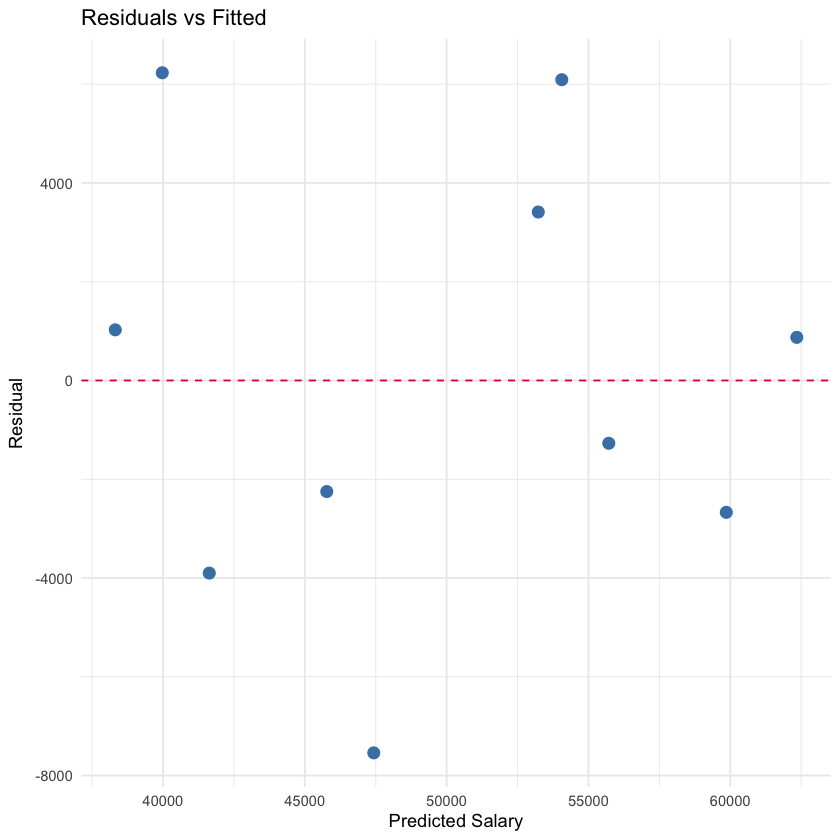

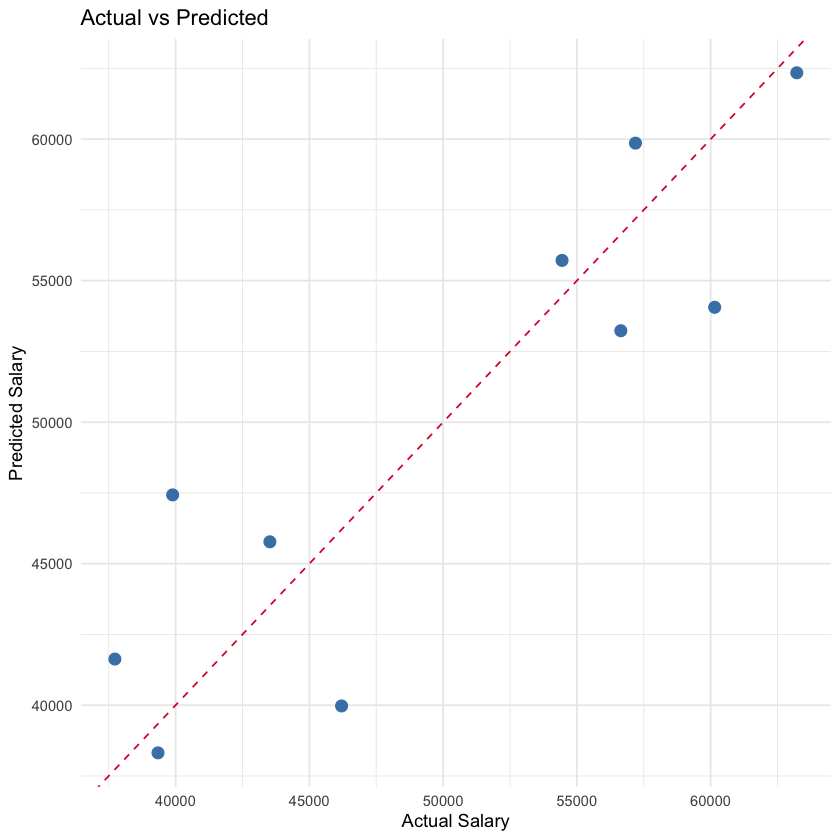

In [10]:
if (has_ggplot2) {
  diag_df <- data.frame(Predicted = y_pred, Residual = residuals_vec, Actual = y)

  p1 <- ggplot(diag_df, aes(x = Predicted, y = Residual)) +
    geom_point(color = "steelblue", size = 3) +
    geom_hline(yintercept = 0, color = "#DC143C", linetype = "dashed") +
    labs(title = "Residuals vs Fitted", x = "Predicted Salary", y = "Residual") +
    theme_minimal()

  p2 <- ggplot(diag_df, aes(x = Actual, y = Predicted)) +
    geom_point(color = "steelblue", size = 3) +
    geom_abline(slope = 1, intercept = 0, color = "#DC143C", linetype = "dashed") +
    labs(title = "Actual vs Predicted", x = "Actual Salary", y = "Predicted Salary") +
    theme_minimal()

  print(p1)
  print(p2)
} else {
  op <- par(mfrow = c(1, 2))
  plot(y_pred, residuals_vec, pch = 19, col = "steelblue",
       xlab = "Predicted Salary", ylab = "Residual",
       main = "Residuals vs Fitted")
  abline(h = 0, col = "#DC143C", lty = 2)

  plot(y, y_pred, pch = 19, col = "steelblue",
       xlab = "Actual Salary", ylab = "Predicted Salary",
       main = "Actual vs Predicted")
  abline(0, 1, col = "#DC143C", lty = 2)
  par(op)
}

## Summary

- The scatter plot shows the relationship between years of experience and salary.
- A simple linear regression was fit with base R `lm()`.
- The regression line was overlaid on the scatter plot.
- Model quality was assessed with R², adjusted R², MAE, MSE/RMSE, ANOVA, and residual plots.